In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv('Combined_dataset.csv')
print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1000, 24)


In [3]:
#Explore Data
print("=== First 5 Rows ===")
print(df.head())

print("\n=== Last 5 Rows ===")
print(df.tail())

print("\n=== Column Names ===")
print(df.columns.tolist())

print("\n=== Data Types ===")
print(df.dtypes)

=== First 5 Rows ===
   product_id           title                         product_description  \
0     8376765     Lino Perros              Women Navy Blue Solid Backpack   
1     9136281  Tommy Hilfiger           Unisex Navy Blue Striped Backpack   
2    17633752           Lavie              Aries Women Pink Mini Backpack   
3     1376949          F Gear  Unisex Navy & Grey Printed Burner Backpack   
4    13939916       MYTRIDENT                    Men Blue Solid Bath Robe   

   rating  ratings_count  initial_price  discount  final_price currency  \
0     3.8             15           3995      58.0  "₹3,995.00"      INR   
1     4.5             67           2899      35.0  "₹2,899.00"      INR   
2     4.4            226           2999      65.0  "₹2,999.00"      INR   
3     4.4           1052           1675      52.0  "₹1,675.00"      INR   
4     4.7             12           2899      17.0  "₹2,899.00"      INR   

                                              images  ...  \
0  h

##### Step 4: Dataset Info & Summary
print("=== Dataset Info ===")
df.info()

print("\n=== Statistical Summary ===")
print(df.describe())

In [4]:
#Check Missing Values
print("=== Missing Values in Each Column ===")
print(df.isnull().sum())

=== Missing Values in Each Column ===
product_id                  0
title                       0
product_description         0
rating                      0
ratings_count               0
initial_price               0
discount                  121
final_price                 0
currency                    0
images                      0
delivery_options            0
product_details             0
breadcrumbs                 0
product_specifications      0
amount_of_stars             0
what_customers_said       573
seller_name               301
sizes                       0
videos                    781
seller_information        301
variations                562
best_offer                  0
more_offers                 0
category                    0
dtype: int64


In [5]:
#Handle Missing Values
# Fill numeric column 'discount' with 0
df['discount'] = df['discount'].fillna(0)
text_cols = ['what_customers_said', 'seller_name', 'seller_information', 'videos', 'variations']
for col in text_cols:
    df[col] = df[col].fillna('Not Available')

# Verify - check missing values again
print("=== Missing Values After Handling ===")
print(df.isnull().sum())

=== Missing Values After Handling ===
product_id                0
title                     0
product_description       0
rating                    0
ratings_count             0
initial_price             0
discount                  0
final_price               0
currency                  0
images                    0
delivery_options          0
product_details           0
breadcrumbs               0
product_specifications    0
amount_of_stars           0
what_customers_said       0
seller_name               0
sizes                     0
videos                    0
seller_information        0
variations                0
best_offer                0
more_offers               0
category                  0
dtype: int64


In [6]:
# Basic Operations - Select Columns & Filter Rows
selected_cols = df[['product_id', 'title', 'category', 'rating', 'initial_price', 'discount']]
print("=== Selected Columns ===")
print(selected_cols.head())
# Filter rows: products with rating above 4.0
high_rated = df[df['rating'] > 4.0]
print("\n=== Products with Rating > 4.0 ===")
print("Total such products:", high_rated.shape[0])
print(high_rated[['title', 'rating']].head())

=== Selected Columns ===
   product_id           title   category  rating  initial_price  discount
0     8376765     Lino Perros  backpacks     3.8           3995      58.0
1     9136281  Tommy Hilfiger  backpacks     4.5           2899      35.0
2    17633752           Lavie  backpacks     4.4           2999      65.0
3     1376949          F Gear  backpacks     4.4           1675      52.0
4    13939916       MYTRIDENT  bath-robe     4.7           2899      17.0

=== Products with Rating > 4.0 ===
Total such products: 533
            title  rating
1  Tommy Hilfiger     4.5
2           Lavie     4.4
3          F Gear     4.4
4       MYTRIDENT     4.7
5             H&M     4.5


In [7]:
# Remove Duplicates

print("Total rows before removing duplicates:", df.shape[0])

# Check duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows found:", duplicate_count)

# Remove duplicates
df = df.drop_duplicates()

print("Total rows after removing duplicates:", df.shape[0])

Total rows before removing duplicates: 1000
Number of duplicate rows found: 0
Total rows after removing duplicates: 1000


In [8]:
# Create Derived Column (total_amount = price * quantity)
df['quantity'] = 1
df['total_amount'] = df['initial_price'] * df['quantity']

print("=== Derived Column Created ===")
print(df[['title', 'initial_price', 'quantity', 'total_amount']].head()) 

=== Derived Column Created ===
            title  initial_price  quantity  total_amount
0     Lino Perros           3995         1          3995
1  Tommy Hilfiger           2899         1          2899
2           Lavie           2999         1          2999
3          F Gear           1675         1          1675
4       MYTRIDENT           2899         1          2899


In [9]:
#  Save Cleaned Dataset as New CSV

df.to_csv('cleaned_shopping_dataset.csv', index=False)

print("Cleaned dataset saved successfully as 'cleaned_shopping_dataset.csv'!")
print("Final shape of cleaned dataset:", df.shape)

Cleaned dataset saved successfully as 'cleaned_shopping_dataset.csv'!
Final shape of cleaned dataset: (1000, 26)


In [10]:
# Final Summary

print("=" * 50)
print("BRIEF SUMMARY OF DATA CLEANING")
print("=" * 50)

print(f"""
1. Dataset loaded: Combined_dataset.csv with 1000 rows and 24 columns.
2. Explored data using head(), tail(), shape, columns, and dtypes.
3. Missing values were found in 6 columns (discount, what_customers_said, 
   seller_name, videos, seller_information, variations). Numeric column 
   'discount' was filled with 0, and text columns were filled with 
   'Not Available'.
4. Performed basic operations: selected key columns and filtered 
   products with rating > 4.0 (533 products found).
5. Checked for duplicate rows - none were found.
6. Created a derived column 'total_amount' = initial_price * quantity 
   (quantity assumed as 1 since this is product-listing data, not 
   order data).
7. Final cleaned dataset saved as 'cleaned_shopping_dataset.csv' 
   with shape (1000, 26).
""")

BRIEF SUMMARY OF DATA CLEANING

1. Dataset loaded: Combined_dataset.csv with 1000 rows and 24 columns.
2. Explored data using head(), tail(), shape, columns, and dtypes.
3. Missing values were found in 6 columns (discount, what_customers_said, 
   seller_name, videos, seller_information, variations). Numeric column 
   'discount' was filled with 0, and text columns were filled with 
   'Not Available'.
4. Performed basic operations: selected key columns and filtered 
   products with rating > 4.0 (533 products found).
5. Checked for duplicate rows - none were found.
6. Created a derived column 'total_amount' = initial_price * quantity 
   (quantity assumed as 1 since this is product-listing data, not 
   order data).
7. Final cleaned dataset saved as 'cleaned_shopping_dataset.csv' 
   with shape (1000, 26).



In [13]:
# Step 11: Convert price-related columns to numeric format

# 'final_price' has ₹ symbol, commas, and quote marks - clean all of them
df['final_price'] = df['final_price'].astype(str)
df['final_price'] = df['final_price'].str.replace('₹', '', regex=False)
df['final_price'] = df['final_price'].str.replace(',', '', regex=False)
df['final_price'] = df['final_price'].str.replace('"', '', regex=False)
df['final_price'] = df['final_price'].str.strip()
df['final_price'] = df['final_price'].astype(float)

print("Data type of final_price after conversion:", df['final_price'].dtype)
print(df[['initial_price', 'final_price']].head())

Data type of final_price after conversion: float64
   initial_price  final_price
0           3995       3995.0
1           2899       2899.0
2           2999       2999.0
3           1675       1675.0
4           2899       2899.0


In [14]:
# Step 12: Feature Engineering

# 1. Price difference column (initial_price vs final_price)
df['price_difference'] = df['initial_price'] - df['final_price']

# 2. Popularity metric (using rating and ratings_count)
df['popularity_score'] = df['rating'] * df['ratings_count']

print("=== New Feature Columns ===")
print(df[['title', 'initial_price', 'final_price', 'price_difference', 'rating', 'ratings_count', 'popularity_score']].head())

=== New Feature Columns ===
            title  initial_price  final_price  price_difference  rating  \
0     Lino Perros           3995       3995.0               0.0     3.8   
1  Tommy Hilfiger           2899       2899.0               0.0     4.5   
2           Lavie           2999       2999.0               0.0     4.4   
3          F Gear           1675       1675.0               0.0     4.4   
4       MYTRIDENT           2899       2899.0               0.0     4.7   

   ratings_count  popularity_score  
0             15              57.0  
1             67             301.5  
2            226             994.4  
3           1052            4628.8  
4             12              56.4  


In [15]:
# Step 13: Univariate Analysis

print("=== Univariate Analysis ===")

print("\n--- Rating Distribution ---")
print(df['rating'].describe())

print("\n--- Price Distribution (final_price) ---")
print(df['final_price'].describe())

print("\n--- Category Counts ---")
print(df['category'].value_counts())

=== Univariate Analysis ===

--- Rating Distribution ---
count    1000.0000
mean        3.6215
std         1.3744
min         0.0000
25%         3.7000
50%         4.1000
75%         4.3000
max         5.0000
Name: rating, dtype: float64

--- Price Distribution (final_price) ---
count     1000.000000
mean      1706.096000
std       1783.864472
min        199.000000
25%        649.000000
50%       1099.000000
75%       2082.250000
max      17995.000000
Name: final_price, dtype: float64

--- Category Counts ---
category
tops            122
dresses         100
shirts           97
jeans            57
sports-shoes     51
               ... 
tights            1
table-covers      1
swim-tops         1
wall-art          1
yoga-mats         1
Name: count, Length: 97, dtype: int64


In [16]:
# Bivariate Analysis

print("=== Bivariate Analysis ===")

print("\n--- Correlation between Rating and Price ---")
correlation = df['rating'].corr(df['final_price'])
print(f"Correlation coefficient: {correlation:.3f}")

print("\n--- Average Price by Rating Group ---")
df['rating_group'] = pd.cut(df['rating'], bins=[0, 2, 3, 4, 5], labels=['0-2', '2-3', '3-4', '4-5'])
print(df.groupby('rating_group')['final_price'].mean())

print("\n--- Discount vs Rating ---")
print(df[['discount', 'rating']].corr())

=== Bivariate Analysis ===

--- Correlation between Rating and Price ---
Correlation coefficient: 0.085

--- Average Price by Rating Group ---
rating_group
0-2    4167.000000
2-3    1510.033333
3-4    1656.398119
4-5    1824.958724
Name: final_price, dtype: float64

--- Discount vs Rating ---
          discount    rating
discount  1.000000 -0.184076
rating   -0.184076  1.000000


C:\Users\laxmi_o77bl5t\AppData\Local\Temp\ipykernel_107816\3606048143.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('rating_group')['final_price'].mean())


In [17]:
# Step 15: Category-level Analysis

print("=== Category-level Analysis ===")

print("\n--- Top 10 Categories by Average Price ---")
print(df.groupby('category')['final_price'].mean().sort_values(ascending=False).head(10))

print("\n--- Top 10 Categories by Average Rating ---")
print(df.groupby('category')['rating'].mean().sort_values(ascending=False).head(10))

print("\n--- Top 10 Most Popular Categories (by popularity_score) ---")
print(df.groupby('category')['popularity_score'].mean().sort_values(ascending=False).head(10))

=== Category-level Analysis ===

--- Top 10 Categories by Average Price ---
category
trolley-bag     17995.000000
headphones       5832.333333
sherwani         5764.600000
watches          5392.800000
sports-shoes     4228.470588
sunglasses       3480.000000
bath-robe        2899.000000
backpacks        2892.000000
sweatshirts      2838.500000
formal-shoes     2798.416667
Name: final_price, dtype: float64

--- Top 10 Categories by Average Rating ---
category
cutlery                   5.000000
shaving-essentials        4.900000
face-wash-and-cleanser    4.800000
chair-cover               4.700000
bath-robe                 4.700000
track-pants               4.566667
gloves                    4.500000
bathroom-accessories      4.500000
boxers                    4.500000
home-fragrance-set        4.500000
Name: rating, dtype: float64

--- Top 10 Most Popular Categories (by popularity_score) ---
category
boots                    3377.650000
tunics                   2010.300000
face-moisturi

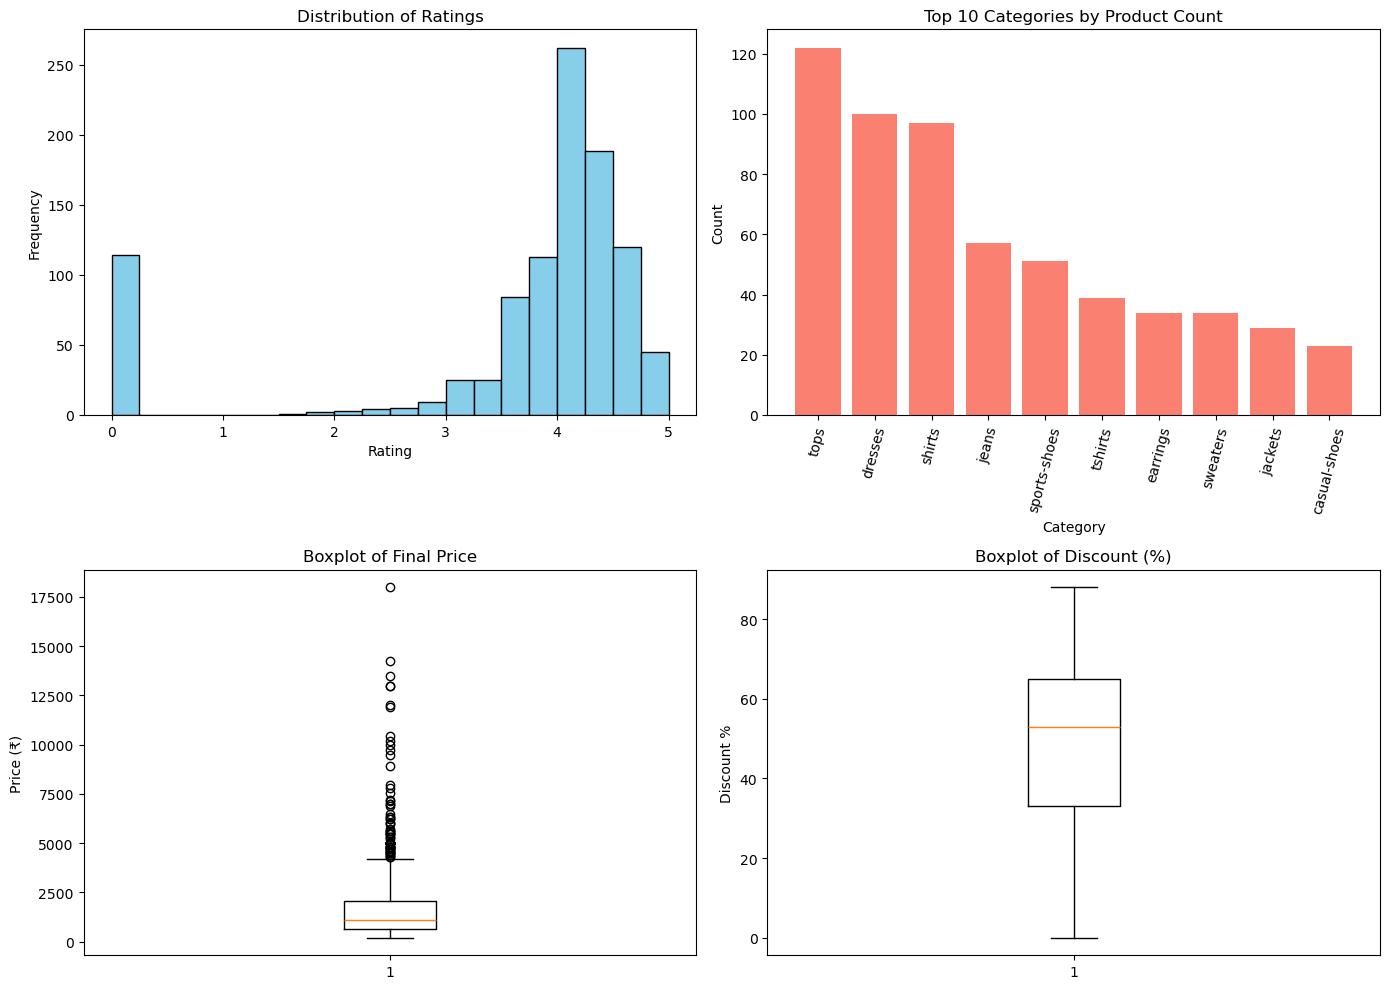

Visualizations created and saved as 'visualizations.png'


In [22]:
# Step 16: Visualization

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram - Rating Distribution
axes[0, 0].hist(df['rating'], bins=20, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Ratings')
axes[0, 0].set_xlabel('Rating')
axes[0, 0].set_ylabel('Frequency')

# 2. Bar Chart - Top 10 Categories by Count
top_categories = df['category'].value_counts().head(10)
axes[0, 1].bar(top_categories.index, top_categories.values, color='salmon')
axes[0, 1].set_title('Top 10 Categories by Product Count')
axes[0, 1].set_xlabel('Category')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=75)

# 3. Boxplot - Price Distribution
axes[1, 0].boxplot(df['final_price'])
axes[1, 0].set_title('Boxplot of Final Price')
axes[1, 0].set_ylabel('Price (₹)')

# 4. Boxplot - Discount Distribution
axes[1, 1].boxplot(df['discount'])
axes[1, 1].set_title('Boxplot of Discount (%)')
axes[1, 1].set_ylabel('Discount %')

plt.tight_layout()
plt.savefig('visualizations.png')
plt.show()

print("Visualizations created and saved as 'visualizations.png'")

In [23]:
# Step 17: Key Insights and Business Implications

print("=" * 60)
print("KEY INSIGHTS FROM ANALYSIS")
print("=" * 60)

print("""
1. RATING DISTRIBUTION:
   Most products have ratings between 4.0-4.5, suggesting overall 
   good product quality. However, ~115 products have 0 rating, 
   likely new listings with no reviews yet.

2. PRICE INSIGHTS:
   Prices range widely from ₹199 to ₹17,995, with most products 
   priced under ₹2,082 (75th percentile). The 'trolley-bag' 
   category has the highest average price.

3. RATING vs PRICE:
   Very weak correlation (0.085) between price and rating - 
   expensive products are NOT necessarily better rated. This 
   suggests pricing strategy should focus on value, not just cost.

4. DISCOUNT vs RATING:
   Slight negative correlation (-0.18) - products with deeper 
   discounts tend to have marginally lower ratings, possibly 
   indicating clearance of lower-performing inventory.

5. CATEGORY PERFORMANCE:
   'Tops' is the most common category (122 products), while 
   'boots' shows the highest popularity score (rating × review 
   count), indicating strong customer engagement despite fewer 
   listings.

BUSINESS IMPLICATION:
Sellers should focus marketing on high-popularity categories 
like boots and tunics, while reconsidering pricing strategy 
for categories with weak rating-price correlation. New product 
listings (0 rating) should be monitored closely to convert them 
into rated, trusted listings.
""")

KEY INSIGHTS FROM ANALYSIS

1. RATING DISTRIBUTION:
   Most products have ratings between 4.0-4.5, suggesting overall 
   good product quality. However, ~115 products have 0 rating, 
   likely new listings with no reviews yet.

2. PRICE INSIGHTS:
   Prices range widely from ₹199 to ₹17,995, with most products 
   priced under ₹2,082 (75th percentile). The 'trolley-bag' 
   category has the highest average price.

3. RATING vs PRICE:
   Very weak correlation (0.085) between price and rating - 
   expensive products are NOT necessarily better rated. This 
   suggests pricing strategy should focus on value, not just cost.

4. DISCOUNT vs RATING:
   Slight negative correlation (-0.18) - products with deeper 
   discounts tend to have marginally lower ratings, possibly 
   indicating clearance of lower-performing inventory.

5. CATEGORY PERFORMANCE:
   'Tops' is the most common category (122 products), while 
   'boots' shows the highest popularity score (rating × review 
   count), indicat